In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D 
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
import pickle

In [2]:
plt.rcParams.update({
    'font.size': 14,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

def add_subplot_label(ax, label, x=-.21, y=1.225):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')

In [3]:
behav_df = pd.read_csv('./data/derivatives/behav_df_cleaned_new.csv')

behav_df = behav_df[behav_df['reach_vis_abs_err']<=60].reset_index(drop=True)

In [4]:
subject_ids = behav_df['subject'].unique()

In [5]:
df_data_implicit = behav_df[behav_df['group'] == 'Implicit']
df_data_explicit = behav_df[behav_df['group'] == 'Explicit']

In [6]:
df_data_implicit_avg = df_data_implicit.groupby(['subject', 'block', 'coh_cat'], as_index=False).mean(numeric_only=True)
df_data_explicit_avg = df_data_explicit.groupby(['subject', 'block', 'coh_cat'], as_index=False).mean(numeric_only=True)

coh_cat_order = ["zero", "low", "med", "high"]

# Convert the 'coh_cat' column to a categorical data type with the desired order
df_data_implicit_avg['coh_cat'] = pd.Categorical(df_data_implicit_avg['coh_cat'], categories=coh_cat_order, ordered=True)
df_data_explicit_avg['coh_cat'] = pd.Categorical(df_data_explicit_avg['coh_cat'], categories=coh_cat_order, ordered=True)


In [7]:
block_0_means_implicit = df_data_implicit_avg['reach_vis_abs_err'][df_data_implicit_avg['block'] == 0]
block_0_means_implicit = np.array(block_0_means_implicit)

for i, subject in enumerate(df_data_implicit_avg['subject'].unique()):
    baseline_value = block_0_means_implicit[i]
    # print(subject, baseline_value)
    df_data_implicit_avg.loc[df_data_implicit_avg['subject'] == subject, 'reach_vis_abs_err_corrected'] = df_data_implicit_avg.loc[df_data_implicit_avg['subject'] == subject, 'reach_vis_abs_err'] - baseline_value

block_0_means_explicit = df_data_explicit_avg['reach_vis_abs_err'][df_data_explicit_avg['block'] == 0]
block_0_means_explicit = np.array(block_0_means_explicit)

for i, subject in enumerate(df_data_explicit_avg['subject'].unique()):
    baseline_value = block_0_means_explicit[i]
    # print(subject, baseline_value)
    df_data_explicit_avg.loc[df_data_explicit_avg['subject'] == subject, 'reach_vis_abs_err_corrected'] = df_data_explicit_avg.loc[df_data_explicit_avg['subject'] == subject, 'reach_vis_abs_err'] - baseline_value

In [8]:
block_0_means_implicit = df_data_implicit_avg['reach_vis_err'][df_data_implicit_avg['block'] == 0]
block_0_means_implicit = np.array(block_0_means_implicit)

for i, subject in enumerate(df_data_implicit_avg['subject'].unique()):
    baseline_value = block_0_means_implicit[i]
    # print(subject, baseline_value)
    df_data_implicit_avg.loc[df_data_implicit_avg['subject'] == subject, 'reach_vis_err_corrected'] = df_data_implicit_avg.loc[df_data_implicit_avg['subject'] == subject, 'reach_vis_err'] - baseline_value

block_0_means_explicit = df_data_explicit_avg['reach_vis_err'][df_data_explicit_avg['block'] == 0]
block_0_means_explicit = np.array(block_0_means_explicit)

for i, subject in enumerate(df_data_explicit_avg['subject'].unique()):
    baseline_value = block_0_means_explicit[i]
    # print(subject, baseline_value)
    df_data_explicit_avg.loc[df_data_explicit_avg['subject'] == subject, 'reach_vis_err_corrected'] = df_data_explicit_avg.loc[df_data_explicit_avg['subject'] == subject, 'reach_vis_err'] - baseline_value

In [9]:
# Baseline Error Values

df_data_implicit_avg_trial = df_data_implicit.groupby(['subject', 'block', 'trial'], as_index=False).mean(numeric_only=True)
df_data_explicit_avg_trial = df_data_explicit.groupby(['subject','block', 'trial'], as_index=False).mean(numeric_only=True)

block_0_means_implicit = df_data_implicit_avg_trial['reach_vis_err'][df_data_implicit_avg_trial['block'] == 0]
block_0_means_implicit = np.array(block_0_means_implicit)

for i, subject in enumerate(df_data_implicit_avg_trial['subject'].unique()):
    baseline_value = block_0_means_implicit[i]
    # print(subject, baseline_value)
    df_data_implicit_avg_trial.loc[df_data_implicit_avg_trial['subject'] == subject, 'reach_vis_err_corrected'] = df_data_implicit_avg_trial.loc[df_data_implicit_avg_trial['subject'] == subject, 'reach_vis_err'] - baseline_value

df_data_implicit_avg_trial_trial_new = df_data_implicit_avg_trial.groupby(['block', 'trial'], as_index=False).mean(numeric_only=True)

block_0_means_explicit = df_data_explicit_avg_trial['reach_vis_err'][df_data_explicit_avg_trial['block'] == 0]
block_0_means_explicit = np.array(block_0_means_explicit)

for i, subject in enumerate(df_data_explicit_avg_trial['subject'].unique()):
    baseline_value = block_0_means_explicit[i]
    # print(subject, baseline_value)
    df_data_explicit_avg_trial.loc[df_data_explicit_avg_trial['subject'] == subject, 'reach_vis_abs_err_corrected'] = df_data_explicit_avg_trial.loc[df_data_explicit_avg_trial['subject'] == subject, 'reach_vis_abs_err'] - baseline_value


# df_data_explicit_avg_trial["reach_vis_err_corrected_abs"] = np.abs(df_data_explicit_avg_trial["reach_vis_err_corrected"])
df_data_explicit_avg_trial_trial_new = df_data_explicit_avg_trial.groupby(['block', 'trial'], as_index=False).mean(numeric_only=True)


In [10]:
# Create a new column for trial index

df_data_implicit_avg_trial_trial_new['trial_idx'] = df_data_implicit_avg_trial_trial_new.groupby('block').cumcount()
df_data_implicit_avg_trial_trial_new['trial_idx'] += df_data_implicit_avg_trial_trial_new['block'] * (df_data_implicit_avg_trial_trial_new['trial'].nunique())

df_data_explicit_avg_trial_trial_new['trial_idx'] = df_data_explicit_avg_trial_trial_new.groupby('block').cumcount()
df_data_explicit_avg_trial_trial_new['trial_idx'] += df_data_explicit_avg_trial_trial_new['block'] * (df_data_explicit_avg_trial_trial_new['trial'].nunique())

# save df_data_implicit_avg_trial_trial_new as behav_df_implicit_trial.csv
#df_data_implicit_avg_trial_trial_new.to_csv('/home/qmoreau/Documents/Beta_bursts/Behavioral/Derivatives/behav_df_implicit_trial.csv')

# save df_data_explicit_avg_trial_trial_new as behav_df_explicit_trial.csv
#df_data_explicit_avg_trial_trial_new.to_csv('/home/qmoreau/Documents/Beta_bursts/Behavioral/Derivatives/behav_df_explicit_trial.csv')


In [11]:
df_data_implicit_avg = df_data_implicit.groupby(['subject', 'block', 'coh_cat'], as_index=False).mean(numeric_only=True)
df_data_explicit_avg = df_data_explicit.groupby(['subject', 'block', 'coh_cat'], as_index=False).mean(numeric_only=True)

coh_cat_order = ["zero", "low", "med", "high"]

# Convert the 'coh_cat' column to a categorical data type with the desired order
df_data_implicit_avg['coh_cat'] = pd.Categorical(df_data_implicit_avg['coh_cat'], categories=coh_cat_order, ordered=True)
df_data_explicit_avg['coh_cat'] = pd.Categorical(df_data_explicit_avg['coh_cat'], categories=coh_cat_order, ordered=True)


In [12]:
block_0_means_implicit = df_data_implicit_avg['reach_vis_err'][df_data_implicit_avg['block'] == 0]
block_0_means_implicit = np.array(block_0_means_implicit)

for i, subject in enumerate(df_data_implicit_avg['subject'].unique()):
    baseline_value = block_0_means_implicit[i]
    # print(subject, baseline_value)
    df_data_implicit_avg.loc[df_data_implicit_avg['subject'] == subject, 'reach_vis_err_corrected'] = df_data_implicit_avg.loc[df_data_implicit_avg['subject'] == subject, 'reach_vis_err'] - baseline_value

block_0_means_explicit = df_data_explicit_avg['reach_vis_err'][df_data_explicit_avg['block'] == 0]
block_0_means_explicit = np.array(block_0_means_explicit)

for i, subject in enumerate(df_data_explicit_avg['subject'].unique()):
    baseline_value = block_0_means_explicit[i]
    # print(subject, baseline_value)
    df_data_explicit_avg.loc[df_data_explicit_avg['subject'] == subject, 'reach_vis_err_corrected'] = df_data_explicit_avg.loc[df_data_explicit_avg['subject'] == subject, 'reach_vis_err'] - baseline_value

In [13]:
block_0_means_implicit = df_data_implicit_avg['reach_vis_abs_err'][df_data_implicit_avg['block'] == 0]
block_0_means_implicit = np.array(block_0_means_implicit)

for i, subject in enumerate(df_data_implicit_avg['subject'].unique()):
    baseline_value = block_0_means_implicit[i]
    # print(subject, baseline_value)
    df_data_implicit_avg.loc[df_data_implicit_avg['subject'] == subject, 'reach_vis_abs_err_corrected'] = df_data_implicit_avg.loc[df_data_implicit_avg['subject'] == subject, 'reach_vis_abs_err'] - baseline_value

block_0_means_explicit = df_data_explicit_avg['reach_vis_abs_err'][df_data_explicit_avg['block'] == 0]
block_0_means_explicit = np.array(block_0_means_explicit)

for i, subject in enumerate(df_data_explicit_avg['subject'].unique()):
    baseline_value = block_0_means_explicit[i]
    # print(subject, baseline_value)
    df_data_explicit_avg.loc[df_data_explicit_avg['subject'] == subject, 'reach_vis_abs_err_corrected'] = df_data_explicit_avg.loc[df_data_explicit_avg['subject'] == subject, 'reach_vis_abs_err'] - baseline_value

/tmp/ipykernel_12410/4006005691.py:148: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  g0 = sns.pointplot(x="block", y="reach_rt", hue="coh_cat", data=df_data_implicit_avg, errorbar="se", ax=axes[2, 0], palette=palette_magma, errwidth=2)
/tmp/ipykernel_12410/4006005691.py:164: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  g1 = sns.pointplot(x="block", y="reach_rt", hue="coh_cat", data=df_data_explicit_avg, errorbar="se", ax=axes[2, 1], palette=palette_mako, errwidth=2)
/tmp/ipykernel_12410/4006005691.py:179: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.pointplot(x="block", y="reach_vis_err_corrected", hue="coh_cat", data=df_data_implicit_avg, errorbar="se", ax=axes[3, 0], palette=palette_magma, errwidth=2)
/tmp/ipykernel_1241

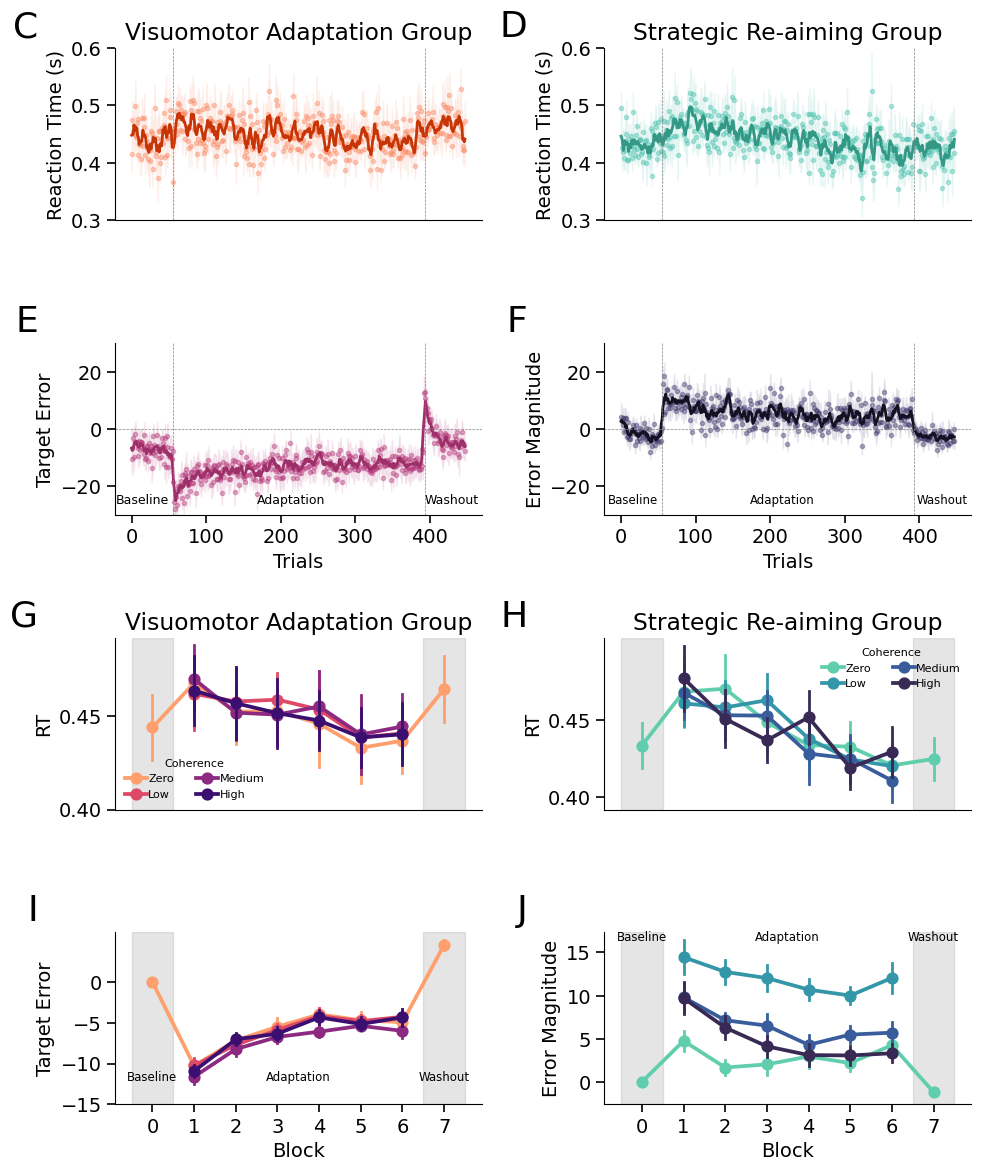

In [14]:
# Calculate standard error for group 0
implicit_rt_std_err = df_data_implicit_avg_trial.groupby(['block', 'trial'])['reach_rt'].sem().values
implicit_vis_err_std_err = df_data_implicit_avg_trial.groupby(['block', 'trial'])['reach_vis_err_corrected'].sem().values

# Calculate standard error for group 1
explicit_rt_std_err = df_data_explicit_avg_trial.groupby(['block', 'trial'])['reach_rt'].sem().values
explicit_vis_err_std_err = df_data_explicit_avg_trial.groupby(['block', 'trial'])['reach_vis_abs_err_corrected'].sem().values

# Define color palettes
palette0 = sns.color_palette("magma_r", 3)
palette1 = sns.color_palette("mako_r", 3)

# Function to compute centered moving average
def moving_average(data, window_size=10):
    if window_size % 2 == 0:
        window_size += 1
    
    half_window = window_size // 2
    smoothed_data = []
    
    for i in range(len(data)):
        window_start = max(0, i - half_window)
        window_end = min(len(data), i + half_window + 1)
        
        window_values = data[window_start:window_end]
        
        smoothed_data.append(np.mean(window_values))
        
    return np.array(smoothed_data)

# Window size for moving average
window_size = 5  # Making it odd for proper centering

# Create a figure with subplots
fig, axes = plt.subplots(4, 2, figsize=(10, 12))

# Plot behavior for group 0 (Reaction Times)
axes[0, 0].plot(df_data_implicit_avg_trial_trial_new["trial_idx"], 
                df_data_implicit_avg_trial_trial_new["reach_rt"], 
                marker='o', linestyle='', color=palette0[0], markersize=3, alpha=0.4)
axes[0, 0].fill_between(df_data_implicit_avg_trial_trial_new["trial_idx"], 
                        df_data_implicit_avg_trial_trial_new["reach_rt"] - implicit_rt_std_err, 
                        df_data_implicit_avg_trial_trial_new["reach_rt"] + implicit_rt_std_err, 
                        color=palette0[0], alpha=0.1)

# Add centered moving average for group 0 (Reaction Times)
ma_x = df_data_implicit_avg_trial_trial_new["trial_idx"]
ma_y = moving_average(df_data_implicit_avg_trial_trial_new["reach_rt"], window_size)
# Use a darker version of the same color for the moving average line
axes[0, 0].plot(ma_x, ma_y, color=sns.set_hls_values(palette0[0], l=0.4), linewidth=2)

axes[0, 0].set_ylim(0.3, 0.6)
axes[0, 0].set_xlabel("Trials")
axes[0, 0].set_ylabel("Reaction Time (s)")
axes[0, 0].set_title("Visuomotor Adaptation Group")
axes[0, 0].axvline(55, linestyle='--', color='gray', linewidth=0.5)
axes[0, 0].axvline(len(df_data_explicit_avg_trial_trial_new["trial_idx"]) - 55, linestyle='--', color='gray', linewidth=0.5)
axes[0, 0].set_xlabel('')
axes[0, 0].set_xticks([])
add_subplot_label(axes[0,0], 'C', x=-.21, y=1.225)

# Plot behavior for group 1 (Reaction Times)
axes[0, 1].plot(df_data_explicit_avg_trial_trial_new["trial_idx"], 
                df_data_explicit_avg_trial_trial_new["reach_rt"], 
                marker='o', linestyle='', color=palette1[0], markersize=3, alpha=0.4)
axes[0, 1].fill_between(df_data_explicit_avg_trial_trial_new["trial_idx"], 
                        df_data_explicit_avg_trial_trial_new["reach_rt"] - explicit_rt_std_err, 
                        df_data_explicit_avg_trial_trial_new["reach_rt"] + explicit_rt_std_err, 
                        color=palette1[0], alpha=0.1)

# Add centered moving average for group 1 (Reaction Times)
ma_x = df_data_explicit_avg_trial_trial_new["trial_idx"]
ma_y = moving_average(df_data_explicit_avg_trial_trial_new["reach_rt"], window_size)
# Use a darker version of the same color for the moving average line
axes[0, 1].plot(ma_x, ma_y, color=sns.set_hls_values(palette1[0], l=0.4), linewidth=2)

axes[0, 1].set_ylim(0.3, 0.6)
axes[0, 1].set_xlabel("Trials")
axes[0, 1].set_ylabel("Reaction Time (s)")
axes[0, 1].set_title("Strategic Re-aiming Group")
axes[0, 1].axvline(55, linestyle='--', color='gray', linewidth=0.5)
axes[0, 1].axvline(len(df_data_explicit_avg_trial_trial_new["trial_idx"]) - 55, linestyle='--', color='gray', linewidth=0.5)
axes[0, 1].set_xlabel('')
axes[0, 1].set_xticks([])
add_subplot_label(axes[0,1], 'D', x=-.21, y=1.225)

# Plot behavior for group 0 (Error Magnitude)
axes[1, 0].plot(df_data_implicit_avg_trial_trial_new["trial_idx"], 
                df_data_implicit_avg_trial_trial_new["reach_vis_err_corrected"], 
                marker='o', linestyle='', color=palette0[1], markersize=3, alpha=0.4)
axes[1, 0].fill_between(df_data_explicit_avg_trial_trial_new["trial_idx"], 
                        df_data_implicit_avg_trial_trial_new["reach_vis_err_corrected"] - implicit_vis_err_std_err, 
                        df_data_implicit_avg_trial_trial_new["reach_vis_err_corrected"] + implicit_vis_err_std_err, 
                        color=palette0[1], alpha=0.1)

# Add centered moving average for group 0 (Error Magnitude)
ma_x = df_data_implicit_avg_trial_trial_new["trial_idx"]
ma_y = moving_average(df_data_implicit_avg_trial_trial_new["reach_vis_err_corrected"], window_size)
# Use a darker version of the same color for the moving average line
axes[1, 0].plot(ma_x, ma_y, color=sns.set_hls_values(palette0[1], l=0.4), linewidth=2)

axes[1, 0].set_ylim(-30, 30)
axes[1, 0].set_xlabel("Trials")
axes[1, 0].set_ylabel("Target Error")
axes[1, 0].axhline(0, linestyle='--', color='gray', linewidth=0.5)
axes[1, 0].axvline(55, linestyle='--', color='gray', linewidth=0.5)
axes[1, 0].axvline(len(df_data_explicit_avg_trial_trial_new["trial_idx"]) - 55, linestyle='--', color='gray', linewidth=0.5)

# add text boxes
axes[1, 0].text(50, -27, "Baseline", fontsize=9, ha='right', va='bottom')
axes[1, 0].text(260, -27, "Adaptation", fontsize=9, ha='right', va='bottom')
axes[1, 0].text(465, -27, "Washout", fontsize=9, ha='right', va='bottom')
add_subplot_label(axes[1,0], 'E', x=-.21, y=1.225)

# Plot behavior for group 1 (Error Magnitude)
axes[1, 1].plot(df_data_explicit_avg_trial_trial_new["trial_idx"], 
                df_data_explicit_avg_trial_trial_new["reach_vis_abs_err_corrected"], 
                marker='o', linestyle='', color=palette1[2], markersize=3, alpha=0.4)
axes[1, 1].fill_between(df_data_explicit_avg_trial_trial_new["trial_idx"], 
                        df_data_explicit_avg_trial_trial_new["reach_vis_abs_err_corrected"] - explicit_vis_err_std_err, 
                        df_data_explicit_avg_trial_trial_new["reach_vis_abs_err_corrected"] + explicit_vis_err_std_err, 
                        color=palette1[2], alpha=0.1)

# Add centered moving average for group 1 (Error Magnitude)
ma_x = df_data_explicit_avg_trial_trial_new["trial_idx"]
ma_y = moving_average(df_data_explicit_avg_trial_trial_new["reach_vis_abs_err_corrected"], window_size)
# Use a darker version of the same color for the moving average line
axes[1, 1].plot(ma_x, ma_y, color=sns.set_hls_values(palette1[2], l=0.1), linewidth=2)

axes[1, 1].set_ylim(-30, 30)
axes[1, 1].set_xlabel("Trials")
axes[1, 1].set_ylabel("Error Magnitude")
axes[1, 1].axhline(0, linestyle='--', color='gray', linewidth=0.5)
axes[1, 1].axvline(55, linestyle='--', color='gray', linewidth=0.5)
axes[1, 1].axvline(len(df_data_explicit_avg_trial_trial_new["trial_idx"]) - 55, linestyle='--', color='gray', linewidth=0.5)

# add text boxes
axes[1, 1].text(50, -27, "Baseline", fontsize=8.5, ha='right', va='bottom')
axes[1, 1].text(260, -27, "Adaptation", fontsize=8.5, ha='right', va='bottom')
axes[1, 1].text(465, -27, "Washout", fontsize=8.5, ha='right', va='bottom')
add_subplot_label(axes[1,1], 'F', x=-.21, y=1.225)

# Define custom palette order
palette_magma = sns.color_palette("magma_r", 4)
palette_mako = sns.color_palette("mako_r", 4)

# Plot behavior for group 0 (RTs) with Magma palette
g0 = sns.pointplot(x="block", y="reach_rt", hue="coh_cat", data=df_data_implicit_avg, errorbar="se", ax=axes[2, 0], palette=palette_magma, errwidth=2)
axes[2, 0].set_xlabel("")
axes[2, 0].set_yticks(np.arange(0.40, 0.5, .05))
axes[2, 0].set_ylabel("RT")
axes[2, 0].set_title("Visuomotor Adaptation Group")
# remove x ticks
axes[2, 0].set_xticks([])
# Custom legend with specific labels
handles, _ = axes[2, 0].get_legend_handles_labels()
axes[2, 0].legend(handles, ["Zero", "Low", "Medium", "High"], loc='lower left', title="Coherence", ncols=2, fontsize=8, title_fontsize=8)
# Add shaded boxes
axes[2, 0].axvspan(-0.5, 0.5, color='gray', alpha=0.2)
axes[2, 0].axvspan(6.5, 7.5, color='gray', alpha=0.2)
add_subplot_label(axes[2,0], 'G', x=-.21, y=1.225)

# Plot behavior for group 1 (RTs)
g1 = sns.pointplot(x="block", y="reach_rt", hue="coh_cat", data=df_data_explicit_avg, errorbar="se", ax=axes[2, 1], palette=palette_mako, errwidth=2)
axes[2, 1].set_xlabel("")
axes[2, 1].set_ylabel("RT")
axes[2, 1].set_yticks(np.arange(0.40, 0.5, .05))
axes[2, 1].set_title("Strategic Re-aiming Group")
axes[2, 1].set_xticks([])
# Custom legend with specific labels
handles, _ = axes[2, 1].get_legend_handles_labels()
axes[2, 1].legend(handles, ["Zero", "Low", "Medium", "High"], loc='upper right', title="Coherence", ncols=2, fontsize=8, title_fontsize=8)
# Add shaded boxes
axes[2, 1].axvspan(-0.5, 0.5, color='gray', alpha=0.2)
axes[2, 1].axvspan(6.5, 7.5, color='gray', alpha=0.2)
add_subplot_label(axes[2,1], 'H', x=-.21, y=1.225)

# Plot behavior for group 0 (Errors)
sns.pointplot(x="block", y="reach_vis_err_corrected", hue="coh_cat", data=df_data_implicit_avg, errorbar="se", ax=axes[3, 0], palette=palette_magma, errwidth=2)
axes[3, 0].set_xlabel("Block")
axes[3, 0].set_yticks(np.arange(-15, 1, 5))
axes[3, 0].set_ylabel("Target Error")
# Add shaded boxes
axes[3, 0].axvspan(-0.5, 0.5, color='gray', alpha=0.2)
axes[3, 0].axvspan(6.5, 7.5, color='gray', alpha=0.2)
axes[3, 0].text(0, -12.5, "Baseline", fontsize=8.5, ha='center', va='bottom')
axes[3, 0].text(3.5, -12.5, "Adaptation", fontsize=8.5, ha='center', va='bottom')
axes[3, 0].text(7, -12.5, "Washout", fontsize=8.5, ha='center', va='bottom')
add_subplot_label(axes[3,0], 'I', x=-.21, y=1.225)

# Plot behavior for group 1 (Errors)
sns.pointplot(x="block", y="reach_vis_abs_err_corrected", hue="coh_cat", data=df_data_explicit_avg, errorbar="se", ax=axes[3, 1], palette=palette_mako, errwidth=2)
axes[3, 1].set_yticks(np.arange(0, 20, 5))
axes[3, 1].set_xlabel("Block")
axes[3, 1].set_ylabel("Error Magnitude")
# Remove the legends
axes[3, 0].get_legend().remove()
axes[3, 1].get_legend().remove()
# Add shaded boxes
axes[3, 1].axvspan(-0.5, 0.5, color='gray', alpha=0.2)
axes[3, 1].axvspan(6.5, 7.5, color='gray', alpha=0.2)
axes[3, 1].text(0, 16, "Baseline", fontsize=8.5, ha='center', va='bottom')
axes[3, 1].text(3.5, 16, "Adaptation", fontsize=8.5, ha='center', va='bottom')
axes[3, 1].text(7, 16, "Washout", fontsize=8.5, ha='center', va='bottom')
add_subplot_label(axes[3,1], 'J', x=-.21, y=1.225)

# Adjust the spacing between subplots
plt.tight_layout()

# save the figure in pdf
plt.savefig(r'./figures/fig_01_behav.pdf', format='pdf', bbox_inches='tight', dpi=600)

# Show the combined plot
# plt.show()

In [15]:
# NET CHANGE IS ZERO IN EXPLICIT 

In [16]:
df_explicit = behav_df[behav_df['group'] == 'Explicit'].copy()

df_explicit_adapt = df_explicit[(df_explicit['block'] >= 1) & (df_explicit['block'] <= 7)].copy()



In [17]:
df_explicit_adapt['prev_perturb'] = df_explicit_adapt.groupby('subject')['trial_perturb'].shift(1)

df_explicit_adapt['perturb_match'] = df_explicit_adapt['trial_perturb'] == df_explicit_adapt['prev_perturb']

df_explicit_adapt['prev_trial'] = df_explicit_adapt.groupby('subject')['trial'].shift(1)

df_clean = df_explicit_adapt[
    (df_explicit_adapt['perturb_match'].notna()) & 
    (df_explicit_adapt['trial_perturb'] != 0) & 
    (df_explicit_adapt['prev_perturb'] != 0) &
    (df_explicit_adapt['block'] == df_explicit_adapt.groupby('subject')['block'].shift(1)) &
    (df_explicit_adapt['trial'] - df_explicit_adapt['prev_trial'] == 1)
].copy()

               Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  reach_vis_abs_err
No. Observations:   3874     Method:              REML             
No. Groups:         18       Scale:               204.9004         
Min. group size:    187      Log-Likelihood:      -15831.4070      
Max. group size:    233      Converged:           Yes              
Mean group size:    215.2                                          
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                22.449    0.915 24.540 0.000 20.656 24.242
C(perturb_match)[T.True] -3.162    0.461 -6.859 0.000 -4.065 -2.258
trial_idx                -0.020    0.004 -5.460 0.000 -0.027 -0.013
Group Var                10.485    0.275                           



/tmp/ipykernel_12410/1943165064.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([same_errors, diff_errors], labels=['Same Perturb', 'Different Perturb'], patch_artist=True)


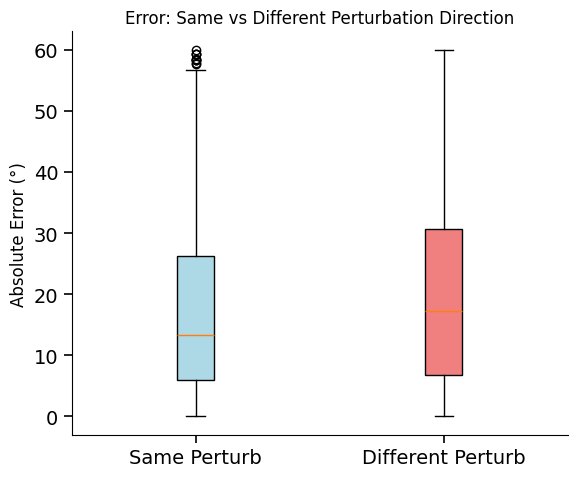

In [18]:
import statsmodels.formula.api as smf

same = df_clean[df_clean['perturb_match'] == True]
diff = df_clean[df_clean['perturb_match'] == False]

# Create trial index
df_clean['trial_idx'] = df_clean.groupby('subject').cumcount()

# Fit LMM with interaction
model = smf.mixedlm("reach_vis_abs_err ~ C(perturb_match) + trial_idx", 
                     df_clean, 
                     groups=df_clean["subject"])
result = model.fit()

print(result.summary())

# Extract stats
p_perturb = result.pvalues['C(perturb_match)[T.True]']
p_trial = result.pvalues['trial_idx']
p_interact = None

# Plot
fig, ax = plt.subplots(figsize=(6, 5))

same_errors = df_clean[df_clean['perturb_match'] == True]['reach_vis_abs_err'].dropna()
diff_errors = df_clean[df_clean['perturb_match'] == False]['reach_vis_abs_err'].dropna()

bp = ax.boxplot([same_errors, diff_errors], labels=['Same Perturb', 'Different Perturb'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightcoral']):
    patch.set_facecolor(color)

ax.set_ylabel('Absolute Error (°)', fontsize=12)
ax.set_title('Error: Same vs Different Perturbation Direction', fontsize=12)


plt.tight_layout()
plt.show()

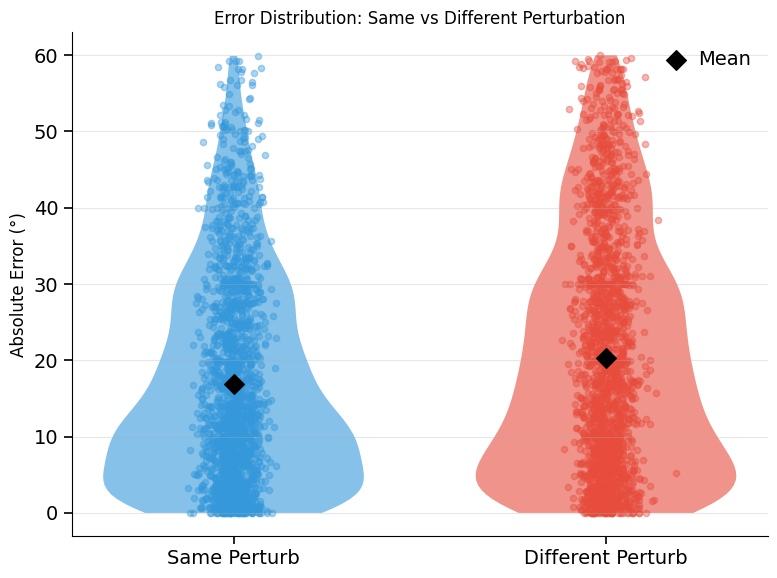

In [19]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

same_errors = df_clean[df_clean['perturb_match'] == True]['reach_vis_abs_err'].dropna()
diff_errors = df_clean[df_clean['perturb_match'] == False]['reach_vis_abs_err'].dropna()

data = [same_errors, diff_errors]
labels = ['Same Perturb', 'Different Perturb']
colors = ['#3498db', '#e74c3c']
positions = [1, 2]

parts = ax.violinplot(data, positions=positions, widths=0.7, showmeans=False, showextrema=False)
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

for pos, values, color in zip(positions, data, colors):
    jitter = np.random.normal(0, 0.04, size=len(values))
    ax.scatter(pos + jitter, values, alpha=0.4, s=20, color=color)

means = [np.mean(same_errors), np.mean(diff_errors)]
ax.scatter(positions, means, color='black', s=100, marker='D', zorder=3, label='Mean')

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel('Absolute Error (°)', fontsize=12)
ax.set_title('Error Distribution: Same vs Different Perturbation', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
import subprocess

df_clean.to_csv('./tmp_data.csv', index=False)

r_script = """
library(lme4)

df_clean <- read.csv('./tmp_data.csv')

model <- glmer(reach_vis_abs_err ~ perturb_match + trial_idx + (1 | subject), 
               data = df_clean, 
               family = Gamma(link = "log"),
               control = glmerControl(optimizer = "bobyqa"))

summary(model)

coefs <- as.data.frame(coef(summary(model)))
write.csv(coefs, './tmp_coefs.csv')
"""

with open('./tmp_script.R', 'w') as f:
    f.write(r_script)

result = subprocess.run(['Rscript', './tmp_script.R'], capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Errors:", result.stderr)

coefs = pd.read_csv('./tmp_coefs.csv', index_col=0)
p_perturb = coefs.loc['perturb_matchTrue', 'Pr(>|z|)']
p_trial = coefs.loc['trial_idx', 'Pr(>|z|)']

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: reach_vis_abs_err ~ perturb_match + trial_idx + (1 | subject)
   Data: df_clean
Control: glmerControl(optimizer = "bobyqa")

     AIC      BIC   logLik deviance df.resid 
 29629.4  29660.7 -14809.7  29619.4     3869 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.2786 -0.8354 -0.2060  0.6625  4.1946 

Random effects:
 Groups   Name        Variance Std.Dev.
 subject  (Intercept) 0.01393  0.1180  
 Residual             0.61173  0.7821  
Number of obs: 3874, groups:  subject, 18

Fixed effects:
                    Estimate Std. Error t value Pr(>|z|)    
(Intercept)        3.0910956  0.0560221  55.176  < 2e-16 ***
perturb_matchTrue -0.1579672  0.0409389  -3.859 0.000114 ***
trial_idx         -0.0009783  0.0003212  -3.045 0.002323 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr

/home/qmoreau/miniconda3/lib/python3.11/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


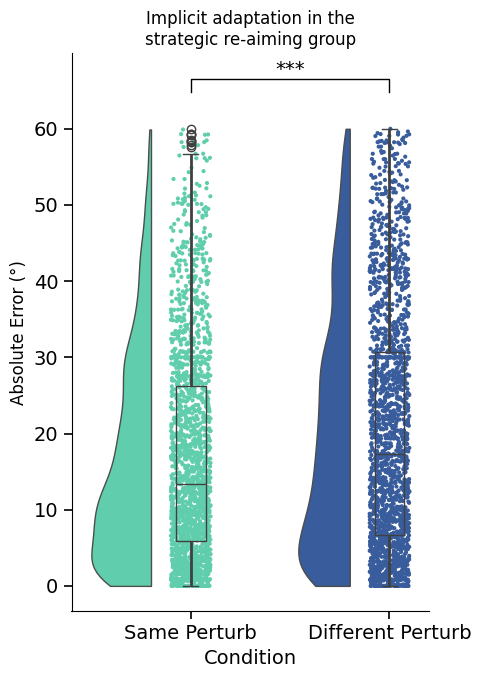

In [21]:
import ptitprince as pt

palette_mako = sns.color_palette("mako_r", 4)

plot_data = pd.concat([
    pd.DataFrame({'Error': same_errors, 'Condition': 'Same Perturb'}),
    pd.DataFrame({'Error': diff_errors, 'Condition': 'Different Perturb'})
])

fig, ax = plt.subplots(figsize=(5, 7))
pt.RainCloud(data=plot_data, x='Condition', y='Error', ax=ax, 
             palette=[palette_mako[0], palette_mako[2]],
             cut=0., width_viol=.6)

ax.set_ylabel('Absolute Error (°)', fontsize=12)
ax.set_title('Implicit adaptation in the\nstrategic re-aiming group', fontsize=12)
ax.set_xlim(-0.6, 1.2)

y_max = plot_data['Error'].max()
y_bracket = y_max * 1.08
h = y_max * 0.03

ax.plot([0, 0, 1, 1], [y_bracket, y_bracket + h, y_bracket + h, y_bracket], color='black', linewidth=1)
ax.text(0.5, y_bracket + h, '***', ha='center', va='bottom', fontsize=14)

plt.tight_layout()
plt.show()

In [22]:

behav_df = pd.read_csv('./data/derivatives/behav_df_cleaned_new.csv')

last_block = behav_df['block'].max()
last_adapt_block = last_block - 1

df_rt = behav_df[behav_df['block'].isin([0, 1, last_adapt_block, last_block])].copy()
df_rt = df_rt[df_rt['reach_rt'].notna()].copy()
df_rt = df_rt[df_rt['group'].notna()].copy()
df_rt = df_rt.reset_index(drop=True)

block_label_map = {0: 'Baseline', 1: 'First Adaptation Block', last_adapt_block: 'Last Adaptation Block', last_block: 'Washout'}
df_rt['block_label'] = df_rt['block'].map(block_label_map)

# Calculate means and SEM for each condition
conditions = []
for group in ['Implicit', 'Explicit']:
    for phase in ['Baseline', 'First Adaptation Block', 'Last Adaptation Block', 'Washout']:
        data = df_rt[(df_rt['group'] == group) & (df_rt['block_label'] == phase)]['reach_rt']
        if len(data) > 0:
            conditions.append({
                'group': group,
                'phase': phase,
                'mean': data.mean(),
                'sem': data.sem(),
                'n': len(data)
            })

cond_df = pd.DataFrame(conditions)

# # Plot
# fig, ax = plt.subplots(figsize=(12, 5))

# bar_width = 0.18
# group_spacing = 1.0
# colors_phase = {'Baseline': '#e8e8e8', 'First Adaptation Block': '#a8c8e1', 'Last Adaptation Block': '#5fa3d8', 'Washout': '#2c5aa0'}
# group_colors = {'Implicit': 'steelblue', 'Explicit': 'coral'}

# for i, group in enumerate(['Implicit', 'Explicit']):
#     group_data = cond_df[cond_df['group'] == group]
    
#     for j, phase in enumerate(['Baseline', 'First Adaptation Block', 'Last Adaptation Block', 'Washout']):
#         phase_data = group_data[group_data['phase'] == phase]
#         if len(phase_data) > 0:
#             phase_data = phase_data.iloc[0]
            
#             x = i * group_spacing + j * bar_width
#             ax.bar(x, phase_data['mean'], bar_width, 
#                    yerr=phase_data['sem'],
#                    capsize=5,
#                    color=colors_phase[phase],
#                    edgecolor=group_colors[group],
#                    linewidth=2,
#                    alpha=0.8)

# # Set x-axis labels
# ax.set_xticks([1.5 * bar_width, group_spacing + 1.5 * bar_width])
# ax.set_xticklabels(['Implicit', 'Explicit'], fontsize=12, fontweight='bold')

# ax.set_ylabel('RT (s)', fontsize=12)
# ax.set_title('Reaction Time: Baseline → Rotation → Late Adaptation → Washout', fontsize=12, fontweight='bold')
# ax.grid(axis='y', alpha=0.3)

# # Add legend
# from matplotlib.patches import Patch
# legend_elements = [Patch(facecolor=colors_phase[phase], edgecolor='black', label=phase) 
#                    for phase in ['Baseline', 'First Adaptation Block', 'Last Adaptation Block', 'Washout']]
# ax.legend(handles=legend_elements, loc='upper right')

# plt.tight_layout()
# plt.show()

In [23]:
import subprocess

df_rt.to_csv('./tmp_data.csv', index=False)

r_script = """
library(lme4)
library(emmeans)

df_rt <- read.csv('./tmp_data.csv')
df_rt$block_label <- factor(df_rt$block_label,
                             levels = c('Baseline', 'First Adaptation Block', 'Last Adaptation Block', 'Washout'))

model <- glmer(reach_rt ~ block_label * group + (1 | subject), 
               data = df_rt, 
               family = Gamma(link = "log"),
               control = glmerControl(optimizer = "bobyqa"))

summary(model)

emm_block <- emmeans(model, ~ block_label | group)
block_vs_baseline <- contrast(emm_block, method = "trt.vs.ctrl", ref = "Baseline", adjust = "holm")
summary(block_vs_baseline)

emm_group <- emmeans(model, ~ group | block_label)
group_diff <- contrast(emm_group, method = "revpairwise", adjust = "holm")
summary(group_diff)

write.csv(as.data.frame(block_vs_baseline), './posthoc_block_vs_baseline.csv', row.names = FALSE)
write.csv(as.data.frame(group_diff), './posthoc_group_diff.csv', row.names = FALSE)
"""

with open('./tmp_script.R', 'w') as f:
    f.write(r_script)

result = subprocess.run(['Rscript', './tmp_script.R'], capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Errors:", result.stderr)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: reach_rt ~ block_label * group + (1 | subject)
   Data: df_rt
Control: glmerControl(optimizer = "bobyqa")

     AIC      BIC   logLik deviance df.resid 
-11121.5 -11051.8   5570.8 -11141.5     7883 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.8883 -0.5609 -0.1367  0.4341  6.1442 

Random effects:
 Groups   Name        Variance Std.Dev.
 subject  (Intercept) 0.003157 0.05619 
 Residual             0.065213 0.25537 
Number of obs: 7893, groups:  subject, 37

Fixed effects:
                                                Estimate Std. Error t value
(Intercept)                                     -0.84482    0.03855 -21.912
block_labelFirst Adaptation Block                0.07442    0.01276   5.834
block_labelLast Adaptation Block                -0.03172    0.01263  -2.511
block_labelWashout                              -0.01964    0.01262  -1.5

In [24]:
# COMPARE THE LAST BLOCK TOO 
# THIS MEAN SOME EXPLICIT LEARNING GOING ON (FOR THE IMPLICIT)

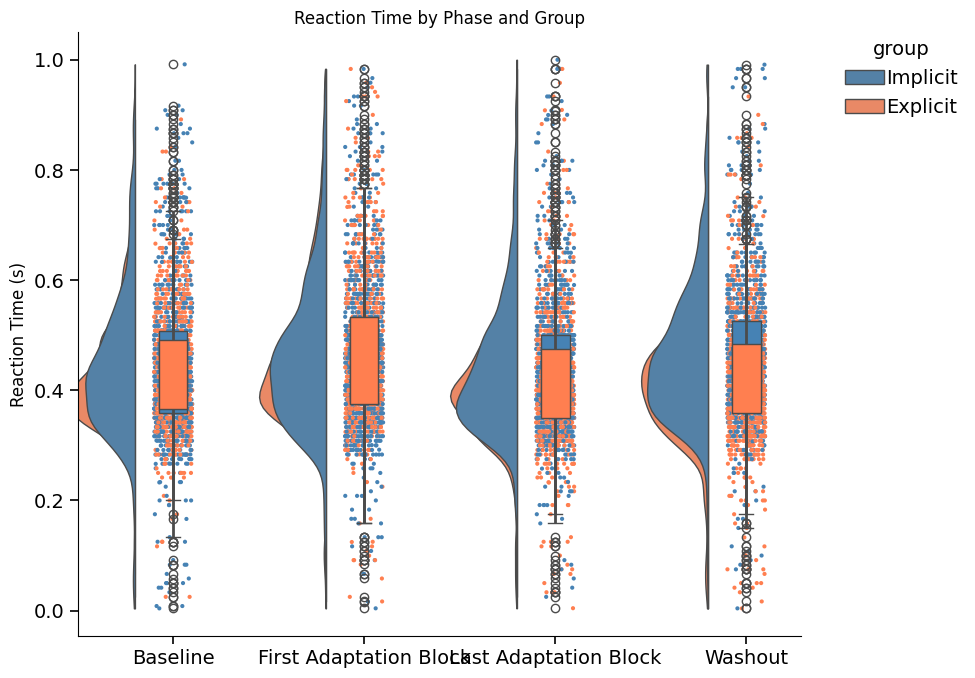

In [25]:
import ptitprince as pt

fig, ax = plt.subplots(figsize=(10, 7))

pt.RainCloud(data=df_rt, x='block_label', y='reach_rt', hue='group',
             order=['Baseline', 'First Adaptation Block', 'Last Adaptation Block', 'Washout'],
             hue_order=['Implicit', 'Explicit'],
             palette=['steelblue', 'coral'], ax=ax)

ax.set_ylabel('Reaction Time (s)', fontsize=12)
ax.set_xlabel('')
ax.set_title('Reaction Time by Phase and Group', fontsize=12)

plt.tight_layout()
plt.show()

/home/qmoreau/miniconda3/lib/python3.11/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/qmoreau/miniconda3/lib/python3.11/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


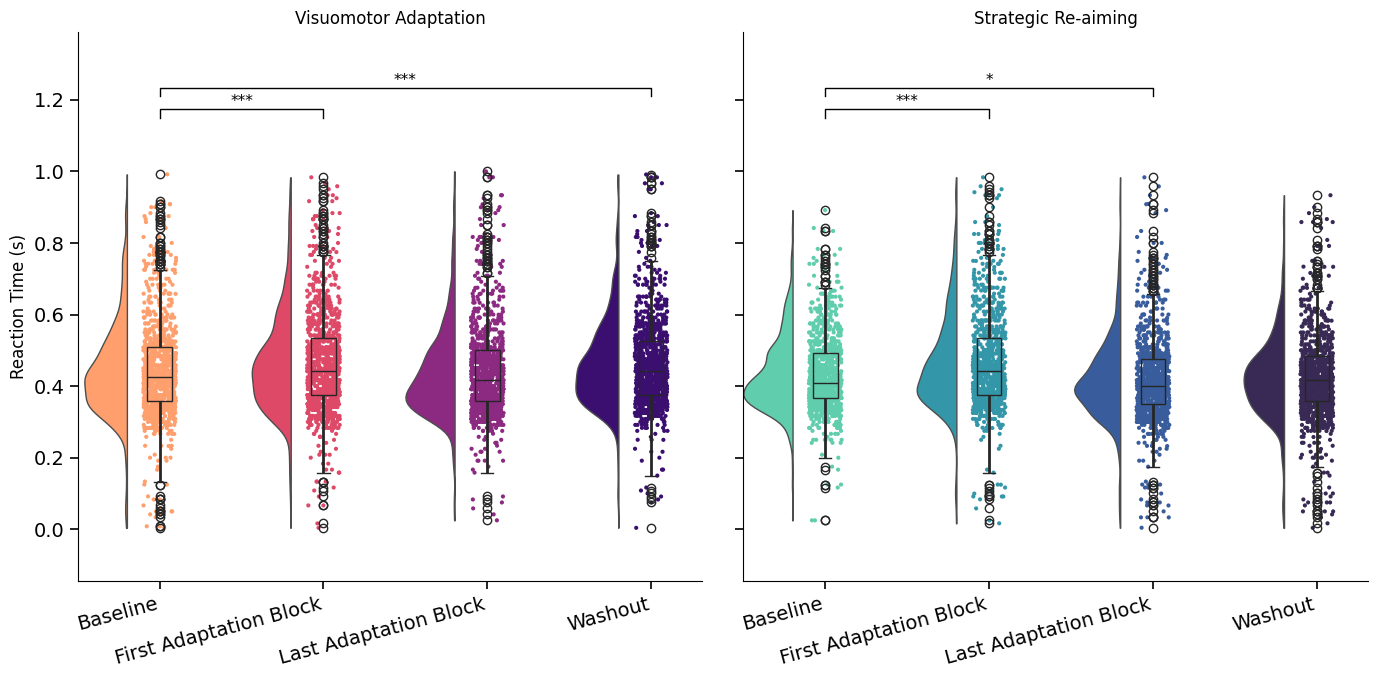

In [26]:
import pandas as pd
from matplotlib.patches import ConnectionPatch

def sig_stars(p):
    if p < .001: return '***'
    if p < .01: return '**'
    if p < .05: return '*'
    return None

def add_bracket(ax, x1, x2, y, h, stars):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, color='black')
    ax.text((x1+x2)/2, y+h, stars, ha='center', va='bottom', fontsize=11)

# Palettes and labels
palette_magma = sns.color_palette("magma_r", 4)
palette_mako = sns.color_palette("mako_r", 4)
group_palettes = {'Implicit': palette_magma, 'Explicit': palette_mako}
group_labels = {'Implicit': 'Visuomotor Adaptation', 'Explicit': 'Strategic Re-aiming'}
block_order = ['Baseline', 'First Adaptation Block', 'Last Adaptation Block', 'Washout']

# Post-hoc results
block_df = pd.read_csv('./posthoc_block_vs_baseline.csv')
group_df = pd.read_csv('./posthoc_group_diff.csv')

# Raincloud panels
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
group_ax = {'Implicit': axes[0], 'Explicit': axes[1]}

for ax, group in zip(axes, ['Implicit', 'Explicit']):
    data = df_rt[df_rt['group'] == group]
    pt.RainCloud(data=data, x='block_label', y='reach_rt',
                 order=block_order,
                 palette=group_palettes[group], ax=ax,
                 cut=0., width_viol=.6)
    ax.set_title(group_labels[group], fontsize=12)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    for label in ax.get_xticklabels():
        label.set_ha('right')

# Y-limits with headroom for brackets
y_min, y_max = df_rt['reach_rt'].min(), df_rt['reach_rt'].max()
margin = (y_max - y_min) * 0.15
step = (y_max - y_min) * 0.06

# Block-vs-baseline stars, per panel
for group, ax in group_ax.items():
    sub = block_df[block_df['group'] == group]
    n_sig = 0
    for _, row in sub.iterrows():
        stars = sig_stars(row['p.value'])
        if stars:
            n_sig += 1
            target_label = row['contrast'].split(' - ')[0].strip()
            x2 = block_order.index(target_label)
            add_bracket(ax, 0, x2, y_max + margin + step * (n_sig - 1), step * 0.4, stars)

axes[0].set_ylim(y_min - margin, y_max + margin + step * 4)

# Washout group-difference bracket (cross-panel)
wash_row = group_df[group_df['block_label'] == 'Washout']
if not wash_row.empty:
    stars = sig_stars(wash_row.iloc[0]['p.value'])
    if stars:
        y_line = y_max + margin + step * 3.2
        con = ConnectionPatch(xyA=(3, y_line), coordsA=axes[0].transData,
                               xyB=(3, y_line), coordsB=axes[1].transData,
                               color='black')
        fig.add_artist(con)
        fig.text(0.5, 0.95, stars, ha='center', fontsize=12)

axes[0].set_ylabel('Reaction Time (s)', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_12410/3284612359.py:137: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.pointplot(x="block", y="reach_rt", hue="coh_cat", data=df_data_implicit_avg, errorbar="se", ax=axes[2, 0], palette=palette_magma, errwidth=2)
/tmp/ipykernel_12410/3284612359.py:149: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.pointplot(x="block", y="reach_rt", hue="coh_cat", data=df_data_explicit_avg, errorbar="se", ax=axes[2, 1], palette=palette_mako, errwidth=2)
/tmp/ipykernel_12410/3284612359.py:162: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.pointplot(x="block", y="reach_vis_err_corrected", hue="coh_cat", data=df_data_implicit_avg, errorbar="se", ax=axes[3, 0], palette=palette_magma, errwidth=2)
/tmp/ipykernel_12410/32846123

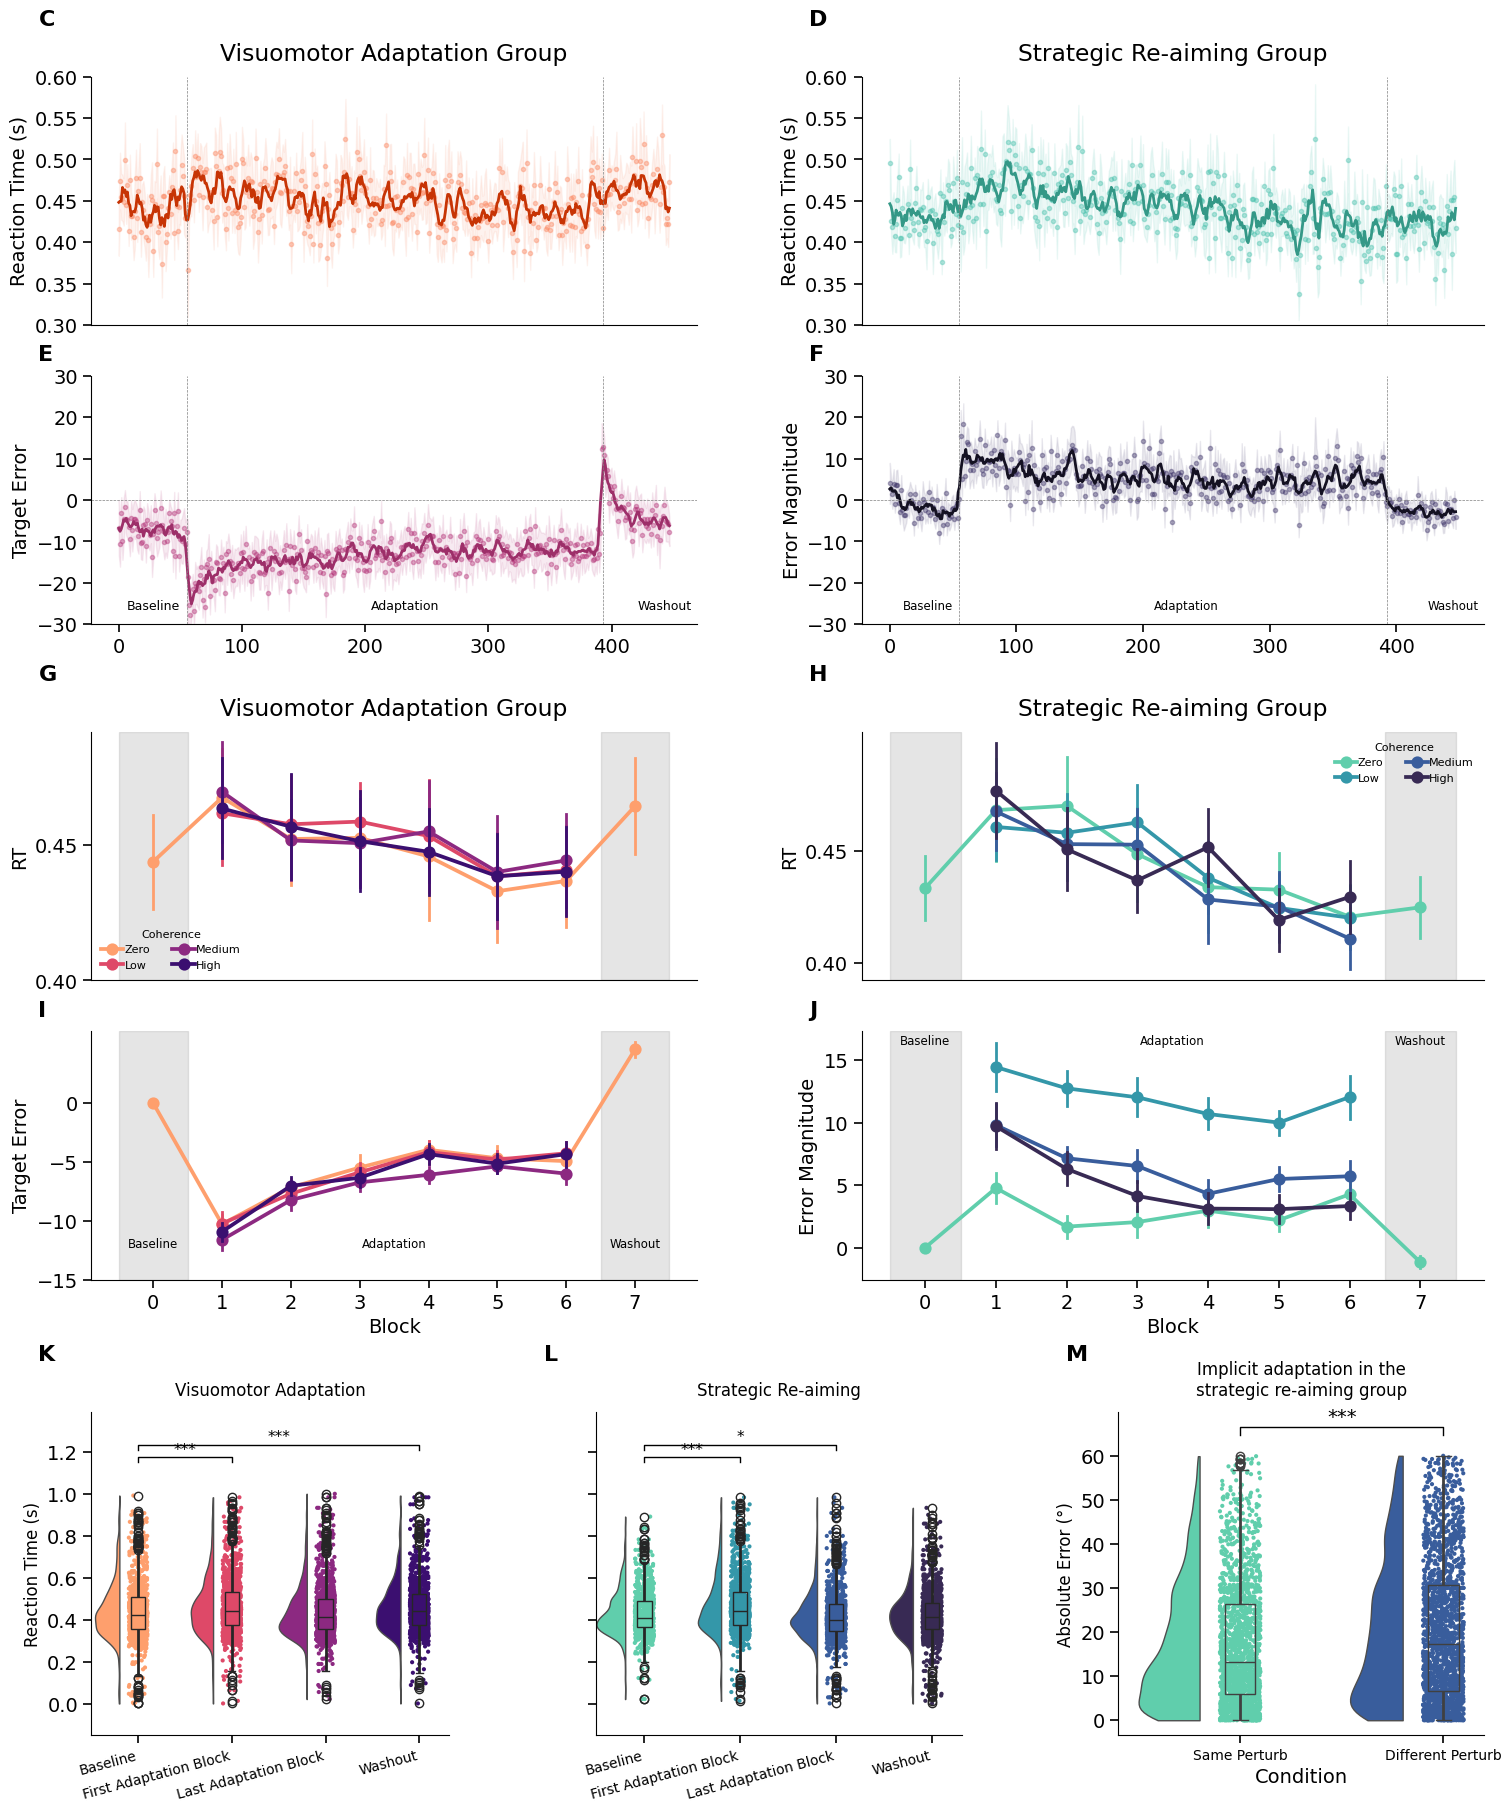

In [27]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import ConnectionPatch

def add_subplot_label(ax, label, has_title=False, fontsize=16, fontweight='bold'):
    dy = 34 if has_title else 8
    ax.annotate(label, xy=(0, 1), xycoords='axes fraction',
                xytext=(-38, dy), textcoords='offset points',
                fontsize=fontsize, fontweight=fontweight, ha='left', va='bottom')

# Calculate standard error for group 0
implicit_rt_std_err = df_data_implicit_avg_trial.groupby(['block', 'trial'])['reach_rt'].sem().values
implicit_vis_err_std_err = df_data_implicit_avg_trial.groupby(['block', 'trial'])['reach_vis_err_corrected'].sem().values

# Calculate standard error for group 1
explicit_rt_std_err = df_data_explicit_avg_trial.groupby(['block', 'trial'])['reach_rt'].sem().values
explicit_vis_err_std_err = df_data_explicit_avg_trial.groupby(['block', 'trial'])['reach_vis_abs_err_corrected'].sem().values

# Define color palettes
palette0 = sns.color_palette("magma_r", 3)
palette1 = sns.color_palette("mako_r", 3)
palette_magma = sns.color_palette("magma_r", 4)
palette_mako = sns.color_palette("mako_r", 4)

def moving_average(data, window_size=10):
    if window_size % 2 == 0:
        window_size += 1
    half_window = window_size // 2
    smoothed_data = []
    for i in range(len(data)):
        window_start = max(0, i - half_window)
        window_end = min(len(data), i + half_window + 1)
        window_values = data[window_start:window_end]
        smoothed_data.append(np.mean(window_values))
    return np.array(smoothed_data)

def sig_stars(p):
    if p < .001: return '***'
    if p < .01: return '**'
    if p < .05: return '*'
    return None

def add_bracket(ax, x1, x2, y, h, stars):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, color='black')
    ax.text((x1+x2)/2, y+h, stars, ha='center', va='bottom', fontsize=11)

window_size = 5

fig = plt.figure(figsize=(15, 18), layout='constrained')
gs = fig.add_gridspec(5, 6, height_ratios=[1, 1, 1, 1, 1.3])

axes = np.empty((4, 2), dtype=object)
for r in range(4):
    axes[r, 0] = fig.add_subplot(gs[r, 0:3])
    axes[r, 1] = fig.add_subplot(gs[r, 3:6])

# --- Panels C/D: Reaction Times ---
axes[0, 0].plot(df_data_implicit_avg_trial_trial_new["trial_idx"], 
                df_data_implicit_avg_trial_trial_new["reach_rt"], 
                marker='o', linestyle='', color=palette0[0], markersize=3, alpha=0.4)
axes[0, 0].fill_between(df_data_implicit_avg_trial_trial_new["trial_idx"], 
                        df_data_implicit_avg_trial_trial_new["reach_rt"] - implicit_rt_std_err, 
                        df_data_implicit_avg_trial_trial_new["reach_rt"] + implicit_rt_std_err, 
                        color=palette0[0], alpha=0.1)
ma_x = df_data_implicit_avg_trial_trial_new["trial_idx"]
ma_y = moving_average(df_data_implicit_avg_trial_trial_new["reach_rt"], window_size)
axes[0, 0].plot(ma_x, ma_y, color=sns.set_hls_values(palette0[0], l=0.4), linewidth=2)
axes[0, 0].set_ylim(0.3, 0.6)
axes[0, 0].set_ylabel("Reaction Time (s)")
axes[0, 0].set_title("Visuomotor Adaptation Group", pad=12)
axes[0, 0].axvline(55, linestyle='--', color='gray', linewidth=0.5)
axes[0, 0].axvline(len(df_data_explicit_avg_trial_trial_new["trial_idx"]) - 55, linestyle='--', color='gray', linewidth=0.5)
axes[0, 0].set_xlabel('')
axes[0, 0].set_xticks([])
add_subplot_label(axes[0,0], 'C', has_title=True)

axes[0, 1].plot(df_data_explicit_avg_trial_trial_new["trial_idx"], 
                df_data_explicit_avg_trial_trial_new["reach_rt"], 
                marker='o', linestyle='', color=palette1[0], markersize=3, alpha=0.4)
axes[0, 1].fill_between(df_data_explicit_avg_trial_trial_new["trial_idx"], 
                        df_data_explicit_avg_trial_trial_new["reach_rt"] - explicit_rt_std_err, 
                        df_data_explicit_avg_trial_trial_new["reach_rt"] + explicit_rt_std_err, 
                        color=palette1[0], alpha=0.1)
ma_x = df_data_explicit_avg_trial_trial_new["trial_idx"]
ma_y = moving_average(df_data_explicit_avg_trial_trial_new["reach_rt"], window_size)
axes[0, 1].plot(ma_x, ma_y, color=sns.set_hls_values(palette1[0], l=0.4), linewidth=2)
axes[0, 1].set_ylim(0.3, 0.6)
axes[0, 1].set_ylabel("Reaction Time (s)")
axes[0, 1].set_title("Strategic Re-aiming Group", pad=12)
axes[0, 1].axvline(55, linestyle='--', color='gray', linewidth=0.5)
axes[0, 1].axvline(len(df_data_explicit_avg_trial_trial_new["trial_idx"]) - 55, linestyle='--', color='gray', linewidth=0.5)
axes[0, 1].set_xlabel('')
axes[0, 1].set_xticks([])
add_subplot_label(axes[0,1], 'D', has_title=True)

# --- Panels E/F: Error Magnitude ---
axes[1, 0].plot(df_data_implicit_avg_trial_trial_new["trial_idx"], 
                df_data_implicit_avg_trial_trial_new["reach_vis_err_corrected"], 
                marker='o', linestyle='', color=palette0[1], markersize=3, alpha=0.4)
axes[1, 0].fill_between(df_data_implicit_avg_trial_trial_new["trial_idx"], 
                        df_data_implicit_avg_trial_trial_new["reach_vis_err_corrected"] - implicit_vis_err_std_err, 
                        df_data_implicit_avg_trial_trial_new["reach_vis_err_corrected"] + implicit_vis_err_std_err, 
                        color=palette0[1], alpha=0.1)
ma_x = df_data_implicit_avg_trial_trial_new["trial_idx"]
ma_y = moving_average(df_data_implicit_avg_trial_trial_new["reach_vis_err_corrected"], window_size)
axes[1, 0].plot(ma_x, ma_y, color=sns.set_hls_values(palette0[1], l=0.4), linewidth=2)
axes[1, 0].set_ylim(-30, 30)
axes[1, 0].set_ylabel("Target Error")
axes[1, 0].axhline(0, linestyle='--', color='gray', linewidth=0.5)
axes[1, 0].axvline(55, linestyle='--', color='gray', linewidth=0.5)
axes[1, 0].axvline(len(df_data_explicit_avg_trial_trial_new["trial_idx"]) - 55, linestyle='--', color='gray', linewidth=0.5)
axes[1, 0].text(50, -27, "Baseline", fontsize=9, ha='right', va='bottom')
axes[1, 0].text(260, -27, "Adaptation", fontsize=9, ha='right', va='bottom')
axes[1, 0].text(465, -27, "Washout", fontsize=9, ha='right', va='bottom')
add_subplot_label(axes[1,0], 'E')

axes[1, 1].plot(df_data_explicit_avg_trial_trial_new["trial_idx"], 
                df_data_explicit_avg_trial_trial_new["reach_vis_abs_err_corrected"], 
                marker='o', linestyle='', color=palette1[2], markersize=3, alpha=0.4)
axes[1, 1].fill_between(df_data_explicit_avg_trial_trial_new["trial_idx"], 
                        df_data_explicit_avg_trial_trial_new["reach_vis_abs_err_corrected"] - explicit_vis_err_std_err, 
                        df_data_explicit_avg_trial_trial_new["reach_vis_abs_err_corrected"] + explicit_vis_err_std_err, 
                        color=palette1[2], alpha=0.1)
ma_x = df_data_explicit_avg_trial_trial_new["trial_idx"]
ma_y = moving_average(df_data_explicit_avg_trial_trial_new["reach_vis_abs_err_corrected"], window_size)
axes[1, 1].plot(ma_x, ma_y, color=sns.set_hls_values(palette1[2], l=0.1), linewidth=2)
axes[1, 1].set_ylim(-30, 30)
axes[1, 1].set_ylabel("Error Magnitude")
axes[1, 1].axhline(0, linestyle='--', color='gray', linewidth=0.5)
axes[1, 1].axvline(55, linestyle='--', color='gray', linewidth=0.5)
axes[1, 1].axvline(len(df_data_explicit_avg_trial_trial_new["trial_idx"]) - 55, linestyle='--', color='gray', linewidth=0.5)
axes[1, 1].text(50, -27, "Baseline", fontsize=8.5, ha='right', va='bottom')
axes[1, 1].text(260, -27, "Adaptation", fontsize=8.5, ha='right', va='bottom')
axes[1, 1].text(465, -27, "Washout", fontsize=8.5, ha='right', va='bottom')
add_subplot_label(axes[1,1], 'F')

# --- Panels G/H: RT by coherence ---
sns.pointplot(x="block", y="reach_rt", hue="coh_cat", data=df_data_implicit_avg, errorbar="se", ax=axes[2, 0], palette=palette_magma, errwidth=2)
axes[2, 0].set_xlabel("")
axes[2, 0].set_yticks(np.arange(0.40, 0.5, .05))
axes[2, 0].set_ylabel("RT")
axes[2, 0].set_title("Visuomotor Adaptation Group", pad=12)
axes[2, 0].set_xticks([])
handles, _ = axes[2, 0].get_legend_handles_labels()
axes[2, 0].legend(handles, ["Zero", "Low", "Medium", "High"], loc='lower left', title="Coherence", ncols=2, fontsize=8, title_fontsize=8)
axes[2, 0].axvspan(-0.5, 0.5, color='gray', alpha=0.2)
axes[2, 0].axvspan(6.5, 7.5, color='gray', alpha=0.2)
add_subplot_label(axes[2,0], 'G', has_title=True)

sns.pointplot(x="block", y="reach_rt", hue="coh_cat", data=df_data_explicit_avg, errorbar="se", ax=axes[2, 1], palette=palette_mako, errwidth=2)
axes[2, 1].set_xlabel("")
axes[2, 1].set_ylabel("RT")
axes[2, 1].set_yticks(np.arange(0.40, 0.5, .05))
axes[2, 1].set_title("Strategic Re-aiming Group", pad=12)
axes[2, 1].set_xticks([])
handles, _ = axes[2, 1].get_legend_handles_labels()
axes[2, 1].legend(handles, ["Zero", "Low", "Medium", "High"], loc='upper right', title="Coherence", ncols=2, fontsize=8, title_fontsize=8)
axes[2, 1].axvspan(-0.5, 0.5, color='gray', alpha=0.2)
axes[2, 1].axvspan(6.5, 7.5, color='gray', alpha=0.2)
add_subplot_label(axes[2,1], 'H', has_title=True)

# --- Panels I/J: Error by coherence ---
sns.pointplot(x="block", y="reach_vis_err_corrected", hue="coh_cat", data=df_data_implicit_avg, errorbar="se", ax=axes[3, 0], palette=palette_magma, errwidth=2)
axes[3, 0].set_xlabel("Block")
axes[3, 0].set_yticks(np.arange(-15, 1, 5))
axes[3, 0].set_ylabel("Target Error")
axes[3, 0].axvspan(-0.5, 0.5, color='gray', alpha=0.2)
axes[3, 0].axvspan(6.5, 7.5, color='gray', alpha=0.2)
axes[3, 0].text(0, -12.5, "Baseline", fontsize=8.5, ha='center', va='bottom')
axes[3, 0].text(3.5, -12.5, "Adaptation", fontsize=8.5, ha='center', va='bottom')
axes[3, 0].text(7, -12.5, "Washout", fontsize=8.5, ha='center', va='bottom')
add_subplot_label(axes[3,0], 'I')

sns.pointplot(x="block", y="reach_vis_abs_err_corrected", hue="coh_cat", data=df_data_explicit_avg, errorbar="se", ax=axes[3, 1], palette=palette_mako, errwidth=2)
axes[3, 1].set_yticks(np.arange(0, 20, 5))
axes[3, 1].set_xlabel("Block")
axes[3, 1].set_ylabel("Error Magnitude")
axes[3, 0].get_legend().remove()
axes[3, 1].get_legend().remove()
axes[3, 1].axvspan(-0.5, 0.5, color='gray', alpha=0.2)
axes[3, 1].axvspan(6.5, 7.5, color='gray', alpha=0.2)
axes[3, 1].text(0, 16, "Baseline", fontsize=8.5, ha='center', va='bottom')
axes[3, 1].text(3.5, 16, "Adaptation", fontsize=8.5, ha='center', va='bottom')
axes[3, 1].text(7, 16, "Washout", fontsize=8.5, ha='center', va='bottom')
add_subplot_label(axes[3,1], 'J')

# --- Panels K/L: RT rainclouds by block ---
group_palettes = {'Implicit': palette_magma, 'Explicit': palette_mako}
group_labels = {'Implicit': 'Visuomotor Adaptation', 'Explicit': 'Strategic Re-aiming'}
block_order = ['Baseline', 'First Adaptation Block', 'Last Adaptation Block', 'Washout']

block_df = pd.read_csv('./posthoc_block_vs_baseline.csv')
group_df = pd.read_csv('./posthoc_group_diff.csv')

df_rt['group'] = df_rt['group'].astype(str).str.strip()

axK = fig.add_subplot(gs[4, 0:2])
axL = fig.add_subplot(gs[4, 2:4], sharey=axK)
raincloud_axes = {'Implicit': axK, 'Explicit': axL}

for group, ax in raincloud_axes.items():
    data = df_rt[df_rt['group'] == group]
    assert len(data) > 0, f"No rows for group={group!r} — check df_rt['group'].unique()"
    ax.clear()
    pt.RainCloud(data=data, x='block_label', y='reach_rt',
                 order=block_order,
                 palette=group_palettes[group], ax=ax,
                 cut=0., width_viol=.6)
    ax.set_title(group_labels[group], fontsize=12, pad=12)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15, labelsize=10)
    for label in ax.get_xticklabels():
        label.set_ha('right')

y_min, y_max = df_rt['reach_rt'].min(), df_rt['reach_rt'].max()
margin = (y_max - y_min) * 0.15
step = (y_max - y_min) * 0.06

for group, ax in raincloud_axes.items():
    sub = block_df[block_df['group'] == group]
    n_sig = 0
    for _, row in sub.iterrows():
        stars = sig_stars(row['p.value'])
        if stars:
            n_sig += 1
            target_label = row['contrast'].split(' - ')[0].strip()
            x2 = block_order.index(target_label)
            add_bracket(ax, 0, x2, y_max + margin + step * (n_sig - 1), step * 0.4, stars)

axK.set_ylim(y_min - margin, y_max + margin + step * 4)
axK.set_ylabel('Reaction Time (s)', fontsize=12)
axL.set_ylabel('')
plt.setp(axL.get_yticklabels(), visible=False)

wash_row = group_df[group_df['block_label'] == 'Washout']
if not wash_row.empty:
    stars = sig_stars(wash_row.iloc[0]['p.value'])
    if stars:
        y_line = y_max + margin + step * 3.2
        con = ConnectionPatch(xyA=(3, y_line), coordsA=axK.transData,
                               xyB=(3, y_line), coordsB=axL.transData,
                               color='black')
        fig.add_artist(con)
        fig.text(0.5, 0.95, stars, ha='center', fontsize=12)

add_subplot_label(axK, 'K', has_title=True)
add_subplot_label(axL, 'L', has_title=True)

# --- Panel M: implicit adaptation within Strategic Re-aiming group ---
axM = fig.add_subplot(gs[4, 4:6])
pt.RainCloud(data=plot_data, x='Condition', y='Error', ax=axM,
             palette=[palette_mako[0], palette_mako[2]],
             cut=0., width_viol=.6)
axM.set_ylabel('Absolute Error (°)', fontsize=12)
axM.set_title('Implicit adaptation in the\nstrategic re-aiming group', fontsize=12, pad=12)
axM.set_xlim(-0.6, 1.2)
axM.tick_params(axis='x', labelsize=10)

y_max_m = plot_data['Error'].max()
y_bracket = y_max_m * 1.08
h = y_max_m * 0.03
axM.plot([0, 0, 1, 1], [y_bracket, y_bracket + h, y_bracket + h, y_bracket], color='black', linewidth=1)
axM.text(0.5, y_bracket + h, '***', ha='center', va='bottom', fontsize=14)

add_subplot_label(axM, 'M', has_title=True)

plt.savefig(r'./figures/fig_01_behav.pdf', format='pdf', bbox_inches='tight', dpi=600)